## Color neurons in 2P space according to their orientation preference

In [5]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from allen_v1dd.client import OPhysClient
from v1dd_public import ARTIFACT_DIR

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
## Load in cell_info dataframe to look at population trends
csv_tag = "_240610"

def load_and_preprocess(file_name, mouse_id):
    # remove duplicate neurons
    df = pd.read_csv(ARTIFACT_DIR / file_name, dtype={'column': str, 'volume': str, '2p3p': str, 'valid_not_duplicate': bool}, low_memory=False)
    df.insert(1, 'mouse_id', mouse_id, True)
    
    # remove all cells in the column 1 that are 2P (keeps the 3P)
    df = df[~((df["column"] == '1') & (df["2p3p"] == '2'))]
    df = df[df["valid_not_duplicate"]]
    return df

# Load and preprocess the data
slc2 = load_and_preprocess(f'slc2_all_stim_metrics{csv_tag}.csv', "slc2")
slc4 = load_and_preprocess(f'slc4_all_stim_metrics{csv_tag}.csv', "slc4")
slc5 = load_and_preprocess(f'slc5_all_stim_metrics{csv_tag}.csv', "slc5")
teto1 = load_and_preprocess(f'teto1_all_stim_metrics{csv_tag}.csv', "teto1")
cell_info = pd.concat([slc2, slc4, slc5, teto1], ignore_index=True)

In [7]:
## Define colors and IDs for each mouse
mouse_colors = {'slc2': "#66CCEE", 'slc4': "#228833", 'slc5': '#CCBB44', 'teto1': '#EE6677'}
mice = ['slc2', 'slc4', 'slc5', 'teto1']
mouse_ids = ["M409828", "M416296", "M427836", "M438833"]

In [10]:
cell_info

,Unnamed: 0.1,mouse_id,Unnamed: 0,valid_cell_index,cell_index,col_vol,column,volume,plane,x,...,dgw_pref_dir,dgf_osi,dgw_osi,dgf_dsi,dgw_dsi,dgf_ls,dgw_ls,ns12_ls,ns118_ls,nm_ls
0,8542,slc2,8542,0,0,16,1,6,0,236,...,150,0.214924,0.485850,0.143261,0.394904,0.650162,0.670042,0.941426,0.943378,0.930728
1,8543,slc2,8543,1,1,16,1,6,0,159,...,90,0.765341,0.699801,0.934434,0.180604,0.914330,0.874348,0.962018,0.940841,0.954807
2,8544,slc2,8544,2,2,16,1,6,0,193,...,240,0.447789,0.317350,0.389030,0.267353,0.655039,0.657950,0.954018,0.956597,0.921463
3,8545,slc2,8545,3,3,16,1,6,0,230,...,0,0.661951,0.464806,0.056502,0.402281,0.667079,0.674886,0.944030,0.944862,0.933212
4,8546,slc2,8546,4,4,16,1,6,0,61,...,330,0.503441,0.748724,0.523120,1.000000,0.684561,0.845968,0.962426,0.954630,0.959651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88346,31308,teto1,31308,1,10,55,5,5,5,75,...,330,0.468661,0.442844,0.431271,0.186935,0.704613,0.650555,0.958025,0.958414,0.939933
88347,31309,teto1,31309,2,14,55,5,5,5,146,...,30,0.472712,0.459277,0.115886,0.715226,0.744843,0.692046,0.960391,0.955787,0.922388
88348,31310,teto1,31310,3,22,55,5,5,5,64,...,30,0.621726,0.329101,0.511249,0.381324,0.752169,0.670320,0.948195,0.958985,0.928885
88349,31311,teto1,31311,4,23,55,5,5,5,81,...,30,0.645523,0.602708,0.314335,0.497443,0.712573,0.708187,0.969706,0.949666,0.934391


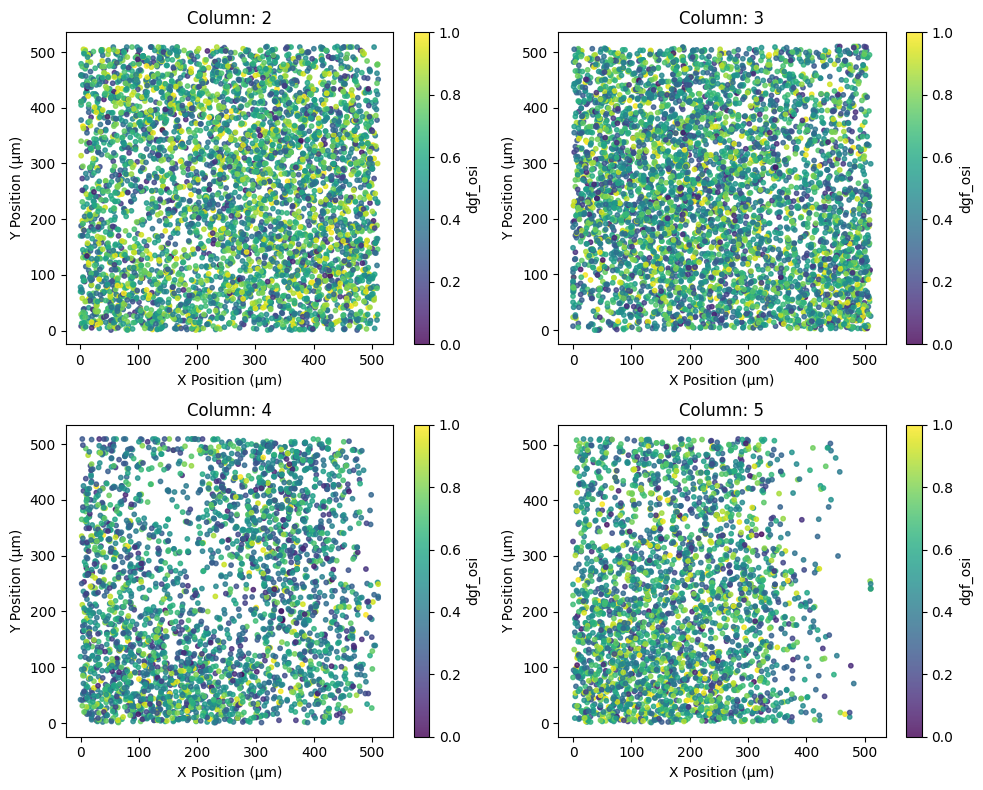

In [37]:
## sample session to visualize
mouse_id = "slc5" #"M427836"
# col_vol_str = "33"
plane = 1
metric = "dgf_osi"

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
for volume in ['1', '2', '3', '4', '5', '6']:
    for i, column in enumerate(['2', '3', '4', '5']):
        for plane in [1, 2, 3, 4, 5, 6]:
            if i < 2:
                ax = axs[0, i]
            else:
                ax = axs[1, i-2]
            col_vol_str = column + volume

            cell_info_sub = cell_info[
                (cell_info['mouse_id'] == mouse_id) & 
                (cell_info['col_vol'] == col_vol_str) &
                (cell_info['plane'] == plane)
            ]
            if len(cell_info_sub) == 0:
                continue
            
            data = cell_info_sub[['x', 'y', metric]]
            ax.scatter(data['x'], data['y'], c=data[metric], cmap='viridis', s=10, alpha=0.8, vmin=0, vmax=1)
        if volume == '6':
            cbar = plt.colorbar(ax.collections[0], ax=ax)
            cbar.set_label(metric)
        # plt.colorbar(sc, ax=ax, label=metric)
        ax.set_title(f'Column: {column}')
        ax.set_xlabel('X Position (µm)')
        ax.set_ylabel('Y Position (µm)')

plt.tight_layout()